<a href="https://colab.research.google.com/github/xFAR3N/Machine-Learning-Introduction/blob/main/Lab28_03_Classification_Methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Used Classifiers methods: NearestCentroid, GaussianNB, MultinomialNB, KNeighboursClassifier, LogisticRegression, DecisionTreeClassifier, RandomForestClassifier, GradientBoostingClassifier and MLP Classifier

To be done in own time: SVC, LinearSVC, LogisticRegressionCV - it takes almost 50 minutes to train on this data set

In [ ]:
from keras.datasets import mnist

In [ ]:
(trainX, trainY), (testX, testY) = mnist.load_data() #load data

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
testY.shape

(10000,)

In [ ]:
import matplotlib.pyplot as plt

6


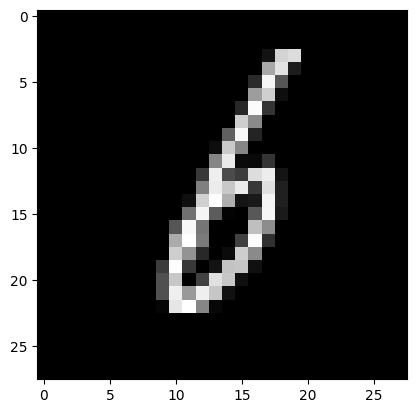

In [ ]:
image = 1906  #display one image for reference
print(trainY[image])
plt.imshow(trainX[image], cmap='gray')

In [ ]:
trainX.shape

(60000, 28, 28)

In [ ]:
trainX = trainX.reshape(60000, 28*28) #reshape 28x28 images to one dimensional vecor
testX = testX.reshape(-1, 28*28) #-1 means that size remains the same

In [ ]:
testX.shape

(10000, 784)

In [ ]:
trainX_01 = trainX / 255 #Change values from 0 - 255 to between 0 and 1 by dividing by max value
testX_01 = testX / 255

In [ ]:
from sklearn.preprocessing import StandardScaler #import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
scaler.fit(trainX)

StandardScaler()

In [ ]:
trainX_std = scaler.transform(trainX) #Standardizing Data - alternatively scale.fit_transform(trainX) without line 16
testX_std = scaler.transform(testX)

In [ ]:
import warnings

In [ ]:
warnings.filterwarnings('ignore')

In [ ]:
import time

In [ ]:
import pandas as pd

In [ ]:
results = pd.DataFrame(columns=('Classifier', 'Rating', 'Training Time', 'Testing Time')) #Create DataFrame that will hold our results

In [ ]:
#this method trains model and add row to our results dataframe
def run(xtr, ytr, xtst, ytst, clf, clf_name):
  global results
  s = time.time()
  model = clf.fit(xtr, ytr)
  time_train = time.time() - s
  s=time.time()
  score_tst = model.score(xtst, ytst)
  time_test = time.time() - s
  print("Rating=%0.4f, Training Time=%8.3f, Testing Time=%8.3f" %(score_tst, time_train, time_test))
  new_row = pd.DataFrame({'Classifier': [clf_name], 'Rating': [score_tst], 'Training Time': [time_train], 'Testing Time': [time_test]})
  results = pd.concat([results, new_row], ignore_index='true')

In [ ]:
#Import models from SciKit Learn
from sklearn.neighbors import KNeighborsClassifier, NearestCentroid
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB, MultinomialNB
from sklearn.neural_network import MLPClassifier

In [ ]:
#A list of models that we are comparing
clfs = [KNeighborsClassifier(), NearestCentroid(), DecisionTreeClassifier(), LogisticRegression(),
        RandomForestClassifier(), GaussianNB(), MultinomialNB(), MLPClassifier()]

In [ ]:
#Model training on 3 datasets - basic, standardized by dividing by max value, standardized with StandardScaler
t_begin = time.time()
print("Model training begins...")
for i in clfs:
  print(i)
  run(trainX, trainY, testX, testY, i, i)
  run(trainX_01, trainY, testX_01, testY, i, str(i)+'_01')
  if str(i)[:13] != 'MultinomialNB':
    run(trainX_std, trainY, testX_std, testY, i, str(i)+'_std')

print("Time elapsed: " + str(time.time()-t_begin))

Model training begins...
KNeighborsClassifier()
Rating=0.9688, Training Time=   0.013, Testing Time=  23.796
Rating=0.9688, Training Time=   0.036, Testing Time=  24.379
Rating=0.9443, Training Time=   0.036, Testing Time=  24.318
NearestCentroid()
Rating=0.8203, Training Time=   0.388, Testing Time=   0.041
Rating=0.8203, Training Time=   0.546, Testing Time=   0.032
Rating=0.8093, Training Time=   0.556, Testing Time=   0.032
DecisionTreeClassifier()
Rating=0.8783, Training Time=  20.469, Testing Time=   0.017
Rating=0.8776, Training Time=  19.046, Testing Time=   0.018
Rating=0.8771, Training Time=  19.629, Testing Time=   0.016
LogisticRegression()
Rating=0.9255, Training Time=  31.997, Testing Time=   0.036
Rating=0.9257, Training Time=  32.870, Testing Time=   0.023
Rating=0.9246, Training Time=  42.077, Testing Time=   0.069
RandomForestClassifier()
Rating=0.9711, Training Time=  51.315, Testing Time=   0.287
Rating=0.9698, Training Time=  43.636, Testing Time=   0.314
Rating=0.

In [ ]:
results.sort_values(["Rating"], ascending=False)

,Classifier,Rating,Training Time,Testing Time
21,MLPClassifier()_01,0.9790,76.295468,0.051795
22,MLPClassifier()_std,0.9727,65.797403,0.051697
12,"(DecisionTreeClassifier(max_features='sqrt', r...",0.9711,51.315143,0.286761
14,RandomForestClassifier()_std,0.9699,45.044546,0.276939
13,RandomForestClassifier()_01,0.9698,43.635649,0.313730
1,KNeighborsClassifier()_01,0.9688,0.035868,24.378634
0,KNeighborsClassifier(),0.9688,0.013487,23.796412
20,MLPClassifier(),0.9663,80.172879,0.069640
2,KNeighborsClassifier()_std,0.9443,0.035846,24.318273
10,LogisticRegression()_01,0.9257,32.869602,0.023119


In [ ]:
import numpy as np
x = np.append(trainX_01, testX_01, axis=0) #Merging our train and test datasets to retrain model with merged dataset
y = np.append(trainY, testY, axis=0)

In [ ]:
x.shape
y.shape

(70000,)

In [ ]:
m = MLPClassifier() #model retraining
model = m.fit(x, y)

In [ ]:
from PIL import Image

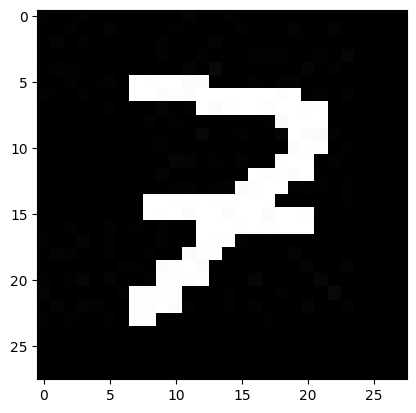

In [ ]:
img = Image.open('7.jpg').convert('L')
plt.imshow(img, cmap='gray')

In [ ]:
im2arr = np.array(img)
im2arr = im2arr.reshape(1, 28*28)

In [ ]:
im2arr = im2arr.astype('float32') / 255

In [ ]:
pred = model.predict(im2arr)
print(pred[0])

7
